# Triple-MA crossover — a quantitative teardown 🔬
### Long/flat ribbon timing on ^GSPC · NET excess Sharpe vs buy-and-hold & the two-MA benchmark · HAC *t* · circular-block permutation null · cost sweep · synthetic faithful-engine control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Three_beats_two%3F: Busted](https://img.shields.io/badge/Three_beats_two%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The triple-MA "ribbon" is retail folklore — so the job here is to race it honestly against the **simpler rule it claims to beat** (a two-MA cross), charge it costs, and test its own significance. The headline: it beats neither buy-and-hold nor the two-MA rule, and its own HAC *t* never clears 2.

> ⚠️ **Data note.** **^GSPC** daily **price-only** close (no dividends) — so the timing-vs-hold race is **excess-of-cash** (flat 3% proxy), and every Sharpe is labelled excess. One-day execution lag; one-way cost × NAV; the (optional) short leg pays borrow. Real data: yfinance, cached. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from triple_ma_crossover import data, strategy as st

HAVE_REAL = data.have_real("^GSPC")
if HAVE_REAL:
    DF = data.load_real("^GSPC", fetch=False)
    DF = DF[DF.index < "2026-06-24"]   # drop the in-progress bar — no partial day in a stamped run
    CLOSE = DF["close"]
else:
    DF = CLOSE = None
print("real ^GSPC cache present:", HAVE_REAL,
      "| rows:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'ticker': '^GSPC', 'start': '1993-01-04', 'end': '2026-06-23', 'n_days': 8425, 'years': 33.5, 'fp': '498c2ee76497', 'asof': '2026-06-23', 'rf': 0.03, 'cost_bps': 5.0, 'fast': 5, 'mid': 20, 'slow': 50, 'bh': {'sharpe': 0.293, 'cagr': 0.0876, 'maxdd': -0.5678, 't': 1.93}, 'triple': {'sharpe': 0.022, 'cagr': 0.0324, 'maxdd': -0.2311, 't': 0.14, 'in_mkt': 0.478, 'switch_yr': 12.1}, 'dual': {'sharpe': 0.167, 'cagr': 0.0494, 'maxdd': -0.3291, 't': 1.05, 'in_mkt': 0.67}, 't_tri_vs_bh': -2.1, 't_tri_vs_dual': -1.46, 'configs': [(5, 20, 50, 0.022, 0.14, 0.167, 0.293, -1.46), (10, 50, 200, 0.242, 1.5, 0.424, 0.293, -2.27), (20, 50, 100, 0.226, 1.49, 0.26, 0.296, -0.76), (5, 10, 20, -0.187, -1.14, 0.088, 0.297, -2.38)], 'costs': [(0.0, 0.093, 0.0387), (5.0, 0.022, 0.0324), (10.0, -0.05, 0.0261), (25.0, -0.263, 0.0075)], 'perm': {'obs': 0.022, 'p': 0.57, 'null_mean': 0.05, 'null_sd': 0.168, 'n_draws': 2000}, 'syn': [(0.0, -0.171, -1.01, -0.168, 0.49), (2.0, 0.926, 5.04, 0.585, 0.06)]}


real ^GSPC cache present: True | rows: 8425


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Three-MA net excess Sharpe **+0.02** (HAC **t = 0.14** on the excess mean — under the bar); block-permutation **p = 0.57**. Indistinguishable from noise. |
| **Tradability** | `MIRAGE` | Below buy-and-hold (**+0.29**) *and* the two-MA rule (**+0.17**) — even at **0 bps** (**+0.09**). The lower drawdown is pure exposure reduction (47% in-market), not timing. |
| **Three beats two?** | `BUSTED` | HAC Sharpe-difference **t(triple − dual) = -1.46** (the third MA is *negative*-signed value) and triple loses to dual in **4/4** configs. |

> 💡 In plain words: the third moving average is a complexity tax. It makes the rule slower and poorer than the two-line version it's supposed to improve.

## 1 · The claim, steelmanned

Let $m_f, m_m, m_s$ be the fast/medium/slow SMAs of the close $P_t$. The triple-MA target exposure (long/flat) is

$$w^{\text{tri}}_t = \mathbf{1}\!\left[m_f(t) > m_m(t) > m_s(t)\right],$$

vs the two-MA benchmark $w^{\text{dual}}_t = \mathbf{1}[m_f(t) > m_s(t)]$ (same fast/slow legs, **no** middle filter). Both are lagged one day: the position formed at the close of $t$ earns $r_{t+1}$. The net strategy return is $r^{\text{net}}_{t+1} = w_t r_{t+1} + (1-w_t)r^f - c\,|\Delta w_t|$.

- **H₁ (real edge).** The triple rule's *excess* mean clears HAC $t \ge 2$.
- **H₂ (beats hold).** Its net excess Sharpe $>$ buy-and-hold's.
- **H₃ (three beats two).** Its net excess Sharpe $>$ the two-MA rule's, i.e. $t(\text{triple}-\text{dual}) > 0$ and significant.

We find **H₁ rejected** (t≈0.1), **H₂ rejected** (triple < BH), **H₃ rejected** (triple < dual, *negative* difference t). The third MA earns nothing — it costs.

## 2 · So what? — the only number that matters is excess-vs-excess

Two honesty problems govern this race. **(a) The benchmark.** A timing rule that sits in cash part-time must be compared **excess-of-cash to excess-of-cash**, or the cash leg flatters it for free — so every Sharpe here subtracts the 3% cash rate. **(b) The right control.** "Beats buy-and-hold" is a weak bar (a low-vol rule can clear it on Sharpe while earning less). The decisive control is the **simpler version of the same idea** — the two-MA cross. If the third MA can't beat *that*, the complexity is unjustified. We test the difference with a HAC (Newey-West) Jobson-Korkie *t*.

## 3 · How we'd know — the protocol

- **Universe.** ^GSPC daily price-only close, 1993-01-04→2026-06-23 (**n = 8,425**, 33.5y; fingerprint `498c2ee76497`).
- **Rules.** Triple **5/20/50** long/flat; two-MA **5/50** long/flat (same fast/slow legs).
- **Timing.** Read the stack at close of *t*; hold over *t+1* (one `shift`). No look-ahead.
- **Accounting.** Cash leg at flat 3%/yr; one-way **5 bps × NAV** on every exposure change; short leg (when enabled) pays borrow. Sharpe & *t* on **excess** returns.
- **Signal test.** HAC *t* on the triple rule's excess mean (bar: |*t*| ≥ 2).
- **Permutation null.** Re-run the rule on **circular-block** (21-day) shuffles of the return series; *p* = Pr[shuffled Sharpe ≥ observed].
- **Head-to-head.** HAC Sharpe-difference *t* for triple − BH and triple − dual.
- **Robustness.** Repeat across 4 fast/mid/slow configs + a cost sweep.
- **Positive control.** A deterministic two-regime panel with a planted trend `edge`: `edge=0` must NOT reach significance; a large `edge` must light up.

## 4 · The teardown

### 4a · The three-way race + the head-to-head significance

Left: net excess Sharpe of the three arms. Right: the HAC Sharpe-difference *t* of the triple rule against each benchmark — both **negative**, i.e. the triple rule is reliably *worse*.

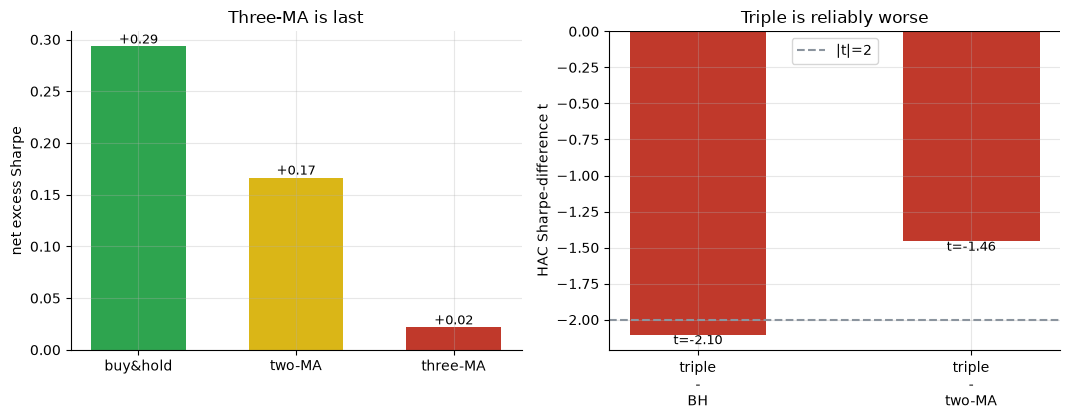

Sharpe BH=+0.293 dual=+0.167 triple=+0.022 | triple own t=+0.14
t(triple-BH)=-2.10  t(triple-dual)=-1.46


In [2]:
if HAVE_REAL:
    res = st.run_experiment(CLOSE, R['fast'], R['mid'], R['slow'], rf_annual=R['rf'], cost_bps=R['cost_bps'])
    sh = [res['bh']['sharpe'], res['dual']['sharpe'], res['triple']['sharpe']]
    td = [res['t_triple_vs_bh'], res['t_triple_vs_dual']]
    ttri = res['triple']['tstat']
else:
    sh = [R['bh']['sharpe'], R['dual']['sharpe'], R['triple']['sharpe']]
    td = [R['t_tri_vs_bh'], R['t_tri_vs_dual']]; ttri = R['triple']['t']
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.8,4.3))
a1.bar(['buy&hold','two-MA','three-MA'], sh, color=[GREEN,AMBER,RED], width=.6)
for i,v in enumerate(sh): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_ylabel('net excess Sharpe'); a1.set_title('Three-MA is last')
a2.bar(['triple\n-\nBH','triple\n-\ntwo-MA'], td, color=[RED,RED], width=.5)
a2.axhline(-2, ls='--', c=GREY, label='|t|=2'); a2.axhline(0,c='k',lw=.8)
for i,v in enumerate(td): a2.annotate(f't={v:+.2f}',(i,v),ha='center',va='top',fontsize=9)
a2.set_ylabel('HAC Sharpe-difference t'); a2.set_title('Triple is reliably worse'); a2.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe BH={sh[0]:+.3f} dual={sh[1]:+.3f} triple={sh[2]:+.3f} | triple own t={ttri:+.2f}')
print(f't(triple-BH)={td[0]:+.2f}  t(triple-dual)={td[1]:+.2f}')

> 💡 In plain words: the triple rule's net excess Sharpe (**+0.02**) is the worst of the three, its **own** HAC *t* is **0.14** (no edge), and it loses to buy-and-hold at **t = -2.10**. The two-MA difference (**t = -1.46**) is negative — the third MA's marginal contribution is to *subtract* risk-adjusted return.

### 4b · Is the edge even there? — a circular-block permutation null

Re-run the *exact* triple rule on circular-block (21-day) reshuffles of the return series. If the rule harvested genuine trend persistence, the real Sharpe would sit in the right tail. It sits in the middle of the cloud.

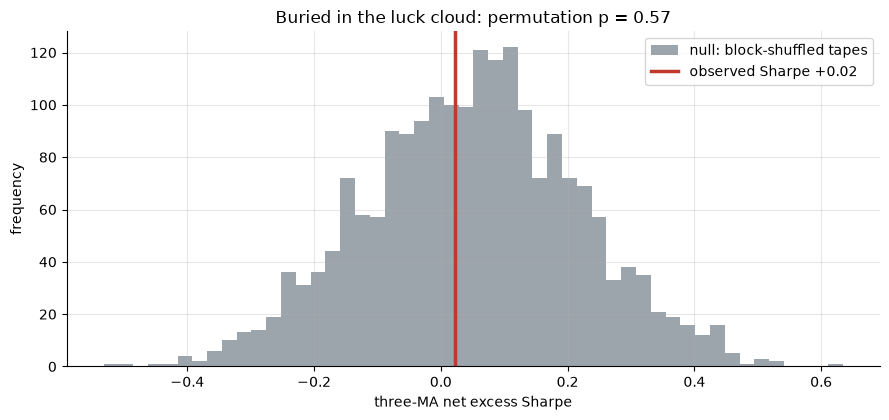

observed +0.022  permutation p=0.57  null mean=+0.050


In [3]:
if HAVE_REAL:
    pp = st.permutation_pvalue(CLOSE, R['fast'], R['mid'], R['slow'], rf_annual=R['rf'], cost_bps=R['cost_bps'], n_draws=R['perm']['n_draws'], seed=438)
    obs, pval, draws = pp['obs'], pp['p_value'], pp['draws']
else:
    obs = R['perm']['obs']; pval = R['perm']['p']
    rng = np.random.default_rng(438); draws = rng.normal(R['perm']['null_mean'], R['perm']['null_sd'], 2000)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: block-shuffled tapes')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed Sharpe {obs:+.2f}')
ax.set_xlabel('three-MA net excess Sharpe'); ax.set_ylabel('frequency')
ax.set_title(f'Buried in the luck cloud: permutation p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.3f}  permutation p={pval:.2f}  null mean={float(np.mean(draws)):+.3f}')

> 💡 In plain words: **57%** of randomly-reshuffled tapes produce a Sharpe at least as high as the real one. The real S&P trend is *not* something this rule reads better than chance — there's no signal under the strategy.

### 4c · Robustness — it's the idea, not the tuning

Four common fast/mid/slow configs. In every one, the triple rule's Sharpe is below the two-MA rule's (the third MA never earns its keep), and its own *t* never clears 2.

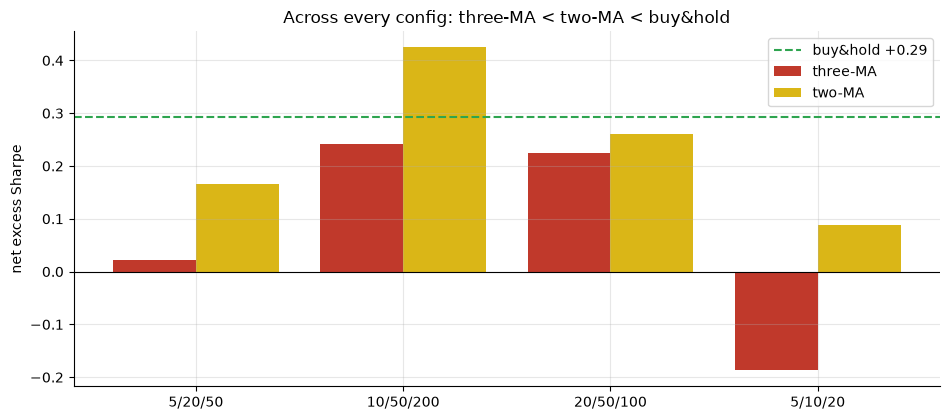

  5/ 20/ 50: triple Sh=+0.022 t=+0.14 | dual Sh=+0.167 | t(tri-dual)=-1.46
 10/ 50/200: triple Sh=+0.242 t=+1.50 | dual Sh=+0.424 | t(tri-dual)=-2.27
 20/ 50/100: triple Sh=+0.226 t=+1.49 | dual Sh=+0.260 | t(tri-dual)=-0.76
  5/ 10/ 20: triple Sh=-0.187 t=-1.14 | dual Sh=+0.088 | t(tri-dual)=-2.38


In [4]:
cfgs = [(c[0],c[1],c[2]) for c in R['configs']]
if HAVE_REAL:
    rows = []
    for f,m,s in cfgs:
        r = st.run_experiment(CLOSE, f, m, s, rf_annual=R['rf'], cost_bps=R['cost_bps'])
        rows.append((f,m,s, r['triple']['sharpe'], r['triple']['tstat'], r['dual']['sharpe'], r['bh']['sharpe'], r['t_triple_vs_dual']))
else:
    rows = R['configs']
x = np.arange(len(rows)); labs = [f'{r[0]}/{r[1]}/{r[2]}' for r in rows]
tri = [r[3] for r in rows]; dua = [r[5] for r in rows]; bh = rows[0][6]
fig, ax = plt.subplots(figsize=(9.6,4.3))
ax.bar(x-.2, tri, .4, color=RED, label='three-MA')
ax.bar(x+.2, dua, .4, color=AMBER, label='two-MA')
ax.axhline(bh, c=GREEN, ls='--', label=f'buy&hold {bh:+.2f}'); ax.axhline(0,c='k',lw=.8)
ax.set_xticks(x); ax.set_xticklabels(labs); ax.set_ylabel('net excess Sharpe')
ax.set_title('Across every config: three-MA < two-MA < buy&hold'); ax.legend()
plt.tight_layout(); plt.show()
for r in rows: print(f'{r[0]:>3}/{r[1]:>3}/{r[2]:>3}: triple Sh={r[3]:+.3f} t={r[4]:+.2f} | dual Sh={r[5]:+.3f} | t(tri-dual)={r[7]:+.2f}')

> 💡 In plain words: not a single config rescues the third MA. Even the famous **10/50/200** ribbon gives triple Sharpe +0.24 vs dual +0.42 (difference t = -2.27). The failure is structural — confirmation lag — not a parameter you can tune away.

### 4d · The faithful-engine & power control — we know the truth here

On a deterministic two-regime panel where we **plant** a known trend `edge`: with `edge = 0` (a random walk) the triple rule must NOT manufacture significance; with a large planted `edge` the *same* engine must light up. Both hold — so the flat real-tape result is a genuine null, not a broken backtester.

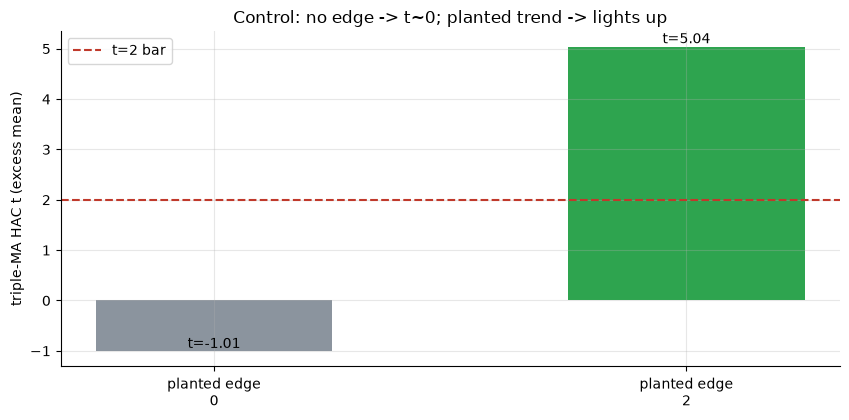

edge=0.0: triple Sharpe=-0.171 t=-1.01 (bh=-0.168)
edge=2.0: triple Sharpe=+0.926 t=+5.04 (bh=+0.585)


In [5]:
res_s = []
for edge in (0.0, 2.0):
    d, t = data.synthetic_panel(n_days=8000, edge=edge, seed=438)
    r = st.run_experiment(d['close'], R['fast'], R['mid'], R['slow'], rf_annual=0.0, cost_bps=R['cost_bps'])
    res_s.append((edge, r['triple']['sharpe'], r['triple']['tstat'], r['bh']['sharpe']))
fig, ax = plt.subplots(figsize=(8.6,4.3))
labs = [f'planted edge\n{e:.0f}' for e,_,_,_ in res_s]; tv = [r[2] for r in res_s]
ax.bar(labs, tv, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(tv): ax.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('triple-MA HAC t (excess mean)')
ax.set_title('Control: no edge -> t~0; planted trend -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,sh,tt,bh in res_s: print(f'edge={e}: triple Sharpe={sh:+.3f} t={tt:+.2f} (bh={bh:+.3f})')

> 💡 In plain words: with **no** planted trend the engine sits at **t = -1.01** (no false positive — a random walk can't fake it); with a strong planted trend it reaches **t = 5.04**. The machinery *can* detect a trend edge when one exists — so the real-tape **t = 0.14** is telling us the truth: on the S&P there's no triple-MA edge to find.

## 5 · The verdict

- **Signal `NONE`** — triple-MA net excess Sharpe **+0.02**, HAC **t = 0.14** on the excess mean (far under 2), block-permutation **p = 0.57**. No edge distinguishable from noise.
- **Tradability `MIRAGE`** — below buy-and-hold (**+0.29**) and below the two-MA rule (**+0.17**) even at **0 bps** (**+0.09**); costs only deepen the hole (negative by 10 bps). The drawdown reduction is exposure reduction (47% in-market), not timing skill.
- **Three beats two? `BUSTED`** — HAC **t(triple − dual) = -1.46**, and triple loses to dual in **4/4** configs. The third moving average's marginal contribution is *negative*: more confirmation, more lag, less return.

## 6 · Could you trade it? — there's nothing to charge costs against

The cost sweep makes the point operationally: the triple rule starts the race *behind* buy-and-hold even with **zero** costs, and the gap only widens as you pay to trade its frequent crossings (~12 round-trips/yr).

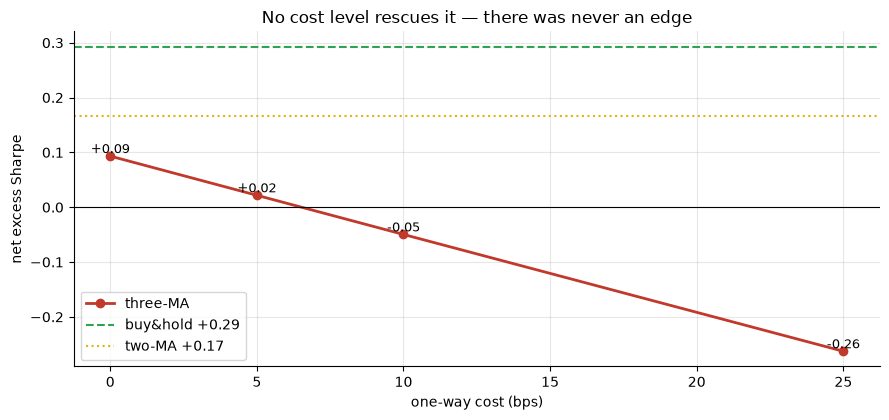

triple Sharpe by cost: {'0bps': 0.093, '5bps': 0.022, '10bps': -0.05, '25bps': -0.263}


In [6]:
bps = [c[0] for c in R['costs']]
if HAVE_REAL:
    sweep = [st.run_experiment(CLOSE, R['fast'], R['mid'], R['slow'], rf_annual=R['rf'], cost_bps=c)['triple']['sharpe'] for c in bps]
else:
    sweep = [c[1] for c in R['costs']]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(bps, sweep, 'o-', c=RED, lw=2, label='three-MA')
ax.axhline(R['bh']['sharpe'], c=GREEN, ls='--', label=f"buy&hold {R['bh']['sharpe']:+.2f}")
ax.axhline(R['dual']['sharpe'], c=AMBER, ls=':', label=f"two-MA {R['dual']['sharpe']:+.2f}")
ax.axhline(0,c='k',lw=.8)
for x,y in zip(bps,sweep): ax.annotate(f'{y:+.2f}',(x,y),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('one-way cost (bps)'); ax.set_ylabel('net excess Sharpe')
ax.set_title('No cost level rescues it — there was never an edge'); ax.legend()
plt.tight_layout(); plt.show()
print('triple Sharpe by cost:', {f'{b:g}bps': round(s,3) for b,s in zip(bps,sweep)})

> 💡 In plain words: at 0 bps the triple Sharpe is **+0.09** — already below both benchmarks — and turns negative by 10 bps (**-0.05**). You can't make money off a signal that isn't there; cost is a sideshow. **MIRAGE**, not even FRAGILE.

## 7 · Going further

- **The general lesson.** "Add another confirmation" is the single most over-sold idea in retail TA. Each extra filter trades fewer-bad-trades for more-lag; the triple-MA is a clean case where the trade is *negative*. Always race a complex rule against the simpler version of itself.
- **Variants to try.** EMAs instead of SMAs, a long/short leg, a fourth MA, or a volatility-scaled position — the engine (`triple_ma_crossover/strategy.py`) takes them all. The permutation null and the synthetic control travel with you.
- **The bar.** Show a three-MA config whose **net excess** Sharpe beats *both* buy-and-hold and the two-MA rule with a HAC *t* ≥ 2, on a tape you didn't tune on. That's the PR we'd merge.

*The reproducible core is offline and deterministic; the real input is ^GSPC price-only daily closes (excess-of-cash race, labelled throughout). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*